# Telco Customer Churn — Logistic Regression vs. XGBoost (Optuna)

End-to-end baseline for the churn classification problem.

**Data:** `data/telco_churn_model.csv` — the merged IBM extended dataset built by
`Telco_Prepare_Merged_Dataset.ipynb` (five source tables joined on `Customer ID`).
It replaces the old single-table Kaggle mirror and adds 15 features that file never
had: `Offer`, `Number of Referrals`, `Avg Monthly GB Download`, `Internet Type`,
`Age`, `Number of Dependents`, `Total Refunds`, `Population`, and others.
Duplicate and leaky columns were already removed at the source, so the cleaning
here is thin by design.

**Pipeline**
1. Load the data
2. Data cleaning / preprocessing
3. Feature engineering
4. Logistic Regression + XGBoost (tuned with Optuna)
5. Metrics: accuracy, precision, recall, F1, ROC-AUC, confusion matrix, ROC curves

> Note: this is the single-model baseline. The UMAP-clustering -> per-cluster
> classification and SHAP -> LLM layers sit on top of this and are not included here.

In [10]:
# If needed, install dependencies (uncomment):
# %pip install -q pandas numpy scikit-learn xgboost optuna matplotlib openpyxl plotly

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, classification_report,
)

import xgboost as xgb
import optuna
import plotly.graph_objects as go

RANDOM_STATE = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(RANDOM_STATE)


## 1. Load the data

In [11]:
DATA_PATH = "data/telco_churn_model.csv"   # built by Telco_Prepare_Merged_Dataset.ipynb

df = pd.read_csv(DATA_PATH)

# "None" is in pandas' default NA list, so the two columns the prep notebook filled
# with it read back as NaN. Restore them as explicit categories: both mean "does not
# have it", which is a fact about the customer, not a missing value.
df["Offer"] = df["Offer"].fillna("No Offer")
df["Internet Type"] = df["Internet Type"].fillna("No Internet")
assert df.isna().sum().sum() == 0, "unexpected nulls after the None round-trip fix"

print("Shape:", df.shape)
df.head()

Shape: (7043, 33)


,Customer ID,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Type,Avg Monthly GB Download,Online Security,...,Total Extra Data Charges,Total Long Distance Charges,Gender,Age,Married,Number of Dependents,Latitude,Longitude,Population,Churn Value
0,8779-QRDMV,0,1,No Offer,No,0.00,No,DSL,8,No,...,20,0.00,Male,78,No,0,34.023810,-118.156582,68701,1
1,7495-OOKFY,1,8,Offer E,Yes,48.85,Yes,Fiber Optic,17,No,...,0,390.80,Female,74,Yes,1,34.044271,-118.185237,55668,1
2,1658-BYGOY,0,18,Offer D,Yes,11.33,Yes,Fiber Optic,52,No,...,0,203.94,Male,71,No,3,34.108833,-118.229715,47534,1
3,4598-XLKNJ,1,25,Offer C,Yes,19.76,No,Fiber Optic,12,No,...,0,494.00,Female,78,Yes,1,33.936291,-118.332639,27778,1
4,4846-WHAFZ,1,37,Offer C,Yes,6.33,Yes,Fiber Optic,14,No,...,0,234.21,Female,80,Yes,1,33.972119,-118.020188,26265,1


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Number of Referrals                7043 non-null   int64  
 2   Tenure in Months                   7043 non-null   int64  
 3   Offer                              7043 non-null   str    
 4   Phone Service                      7043 non-null   str    
 5   Avg Monthly Long Distance Charges  7043 non-null   float64
 6   Multiple Lines                     7043 non-null   str    
 7   Internet Type                      7043 non-null   str    
 8   Avg Monthly GB Download            7043 non-null   int64  
 9   Online Security                    7043 non-null   str    
 10  Online Backup                      7043 non-null   str    
 11  Device Protection Plan             7043 non-null   str    
 12  Pre

## 2. Data cleaning / preprocessing

The heavy lifting already happened in `Telco_Prepare_Merged_Dataset.ipynb`, which
asserts its way through the joins. What it removed, so this notebook does not have to:

- **Leakage** — `Satisfaction Score` (ROC-AUC **0.950** on its own), `Churn Score`
  (**0.943**), `Customer Status`, `Churn Category`, `Churn Reason`, and `CLTV`.
  The first two beat this notebook's fully tuned model single-handed, which is the
  signature of a field recorded *with* the outcome rather than before it.
- **Exact duplicates** — `Under 30`, `Senior Citizen`, `Dependents`,
  `Referred a Friend`, `Internet Service`, `Total Revenue`, `Churn Label`. Each was
  provably a function of a column that survives, and duplicates split the gain between
  twins and make the importance chart understate the real driver.
- **Constants, IDs, and high-cardinality geography** — `City` (1,129 levels) is gone;
  geography survives as `Latitude`, `Longitude`, and `Population`.

What is left to do here: drop `Customer ID`. The IBM tables also arrive already clean —
`Total Charges` is numeric (the old file's 11 blank strings are gone), no customer has
zero tenure, and the service columns are plain `Yes`/`No` with no
`"No internet service"` placeholders to normalize.

## Is Contract ordinal? churn rate by level ===
  Month-to-Month   churn=45.8%
  One Year         churn=10.7%
  Two Year         churn=2.5%

## Is tenure_bucket ordinal? churn rate by bucket ===
  0-3m             churn=59.9%
  4-12m            churn=40.0%
  13-24m           churn=27.0%
  25-48m           churn=19.7%
  48m+             churn=6.5%

## Is Offer ordinal? churn rate by level ===
  Offer A          churn=6.7%
  Offer B          churn=12.3%
  Offer C          churn=22.9%
  Offer D          churn=26.7%
  Offer E          churn=52.9%
  No Offer         churn=27.1%   <- does NOT sit on the A..E ladder

## Is Internet Type ordinal? (nominal check) ===
  DSL              churn=18.6%
  Fiber Optic      churn=40.7%
  Cable            churn=25.7%
  No Internet      churn=7.4%

## Is Payment Method ordinal? (nominal check) ===
  Bank Withdrawal  churn=34.0%
  Credit Card      churn=14.5%
  Mailed Check     churn=36.9%

In [13]:
df = df.copy()

TARGET = "Churn Value"

# The prep notebook already stripped leakage, duplicates, constants and City.
# All that is left is the join key.
df = df.drop(columns=["Customer ID"])

# Re-assert the invariant here rather than trusting the upstream notebook: a leak
# that reaches this frame is a leak in the model.
LEAKY = ["Satisfaction Score", "Customer Status", "Churn Label", "Churn Score",
         "CLTV", "Churn Category", "Churn Reason"]
assert not [c for c in df.columns if c in LEAKY], "leaky column reached the model frame"

print("Remaining shape:", df.shape)

Remaining shape: (7043, 32)


In [14]:
# The old file coded "no internet" as a third level inside every add-on column
# ("No internet service"), which had to be folded into "No". The IBM services table
# does not do that, so there is nothing to normalize -- but verify rather than assume.
service_cols = [
    "Multiple Lines", "Online Security", "Online Backup", "Device Protection Plan",
    "Premium Tech Support", "Streaming TV", "Streaming Movies", "Streaming Music",
    "Unlimited Data",
]
for c in service_cols:
    levels = set(df[c].unique())
    assert levels <= {"Yes", "No"}, f"{c} has unexpected levels: {levels}"
print(f"{len(service_cols)} service columns verified as plain Yes/No")

# Quick target balance
print(df[TARGET].value_counts(normalize=True).round(3).to_dict())

9 service columns verified as plain Yes/No
{0: 0.735, 1: 0.265}


## 3. Feature engineering

Mirrors the behavioral-risk idea from the attrition work: turn raw fields into
churn-risk signals.

- `tenure_bucket` — lifecycle stage
- `num_services` — how many services the customer subscribes to (engagement/stickiness)
- `avg_monthly_spend` — Total / tenure (spend intensity)
- `monthly_to_total_ratio` — early-life spend pressure
- `has_offer` — whether the customer is on a promotional offer at all

**Why `has_offer` exists.** Churn climbs monotonically across `Offer A -> E`
(6.7% -> 52.9%), so the A..E ladder is genuinely ordinal. But *no offer* churns at
27.1%, which lands between C and D — it is not a rung on that ladder, it is a
different state. Encoding it as a sixth ordinal level would assert an order that the
data denies. Splitting it out lets `has_offer` carry the "on an offer at all"
distinction while `Offer` carries the ordered intensity. `Offer` still needs *some*
code for the no-offer rows — it gets 0 as a placeholder, which is harmless precisely
because `has_offer` lets the model condition on it rather than reading 0 as "milder
than Offer A".

No hand-built risk flags beyond that: flags like `is_month_to_month` were removed
earlier because each was an exact duplicate (r = 1.000) of a column the encoder
already produces from `Contract` / `Payment Method` / `tenure_bucket`.

In [15]:
df_fe = df.copy()

# tenure buckets
df_fe["tenure_bucket"] = pd.cut(
    df_fe["Tenure in Months"],
    bins=[-1, 3, 12, 24, 48, np.inf],
    labels=["0-3m", "4-12m", "13-24m", "25-48m", "48m+"],
).astype(str)

# count of services subscribed
count_cols = ["Phone Service", "Multiple Lines", "Online Security", "Online Backup",
              "Device Protection Plan", "Premium Tech Support", "Streaming TV",
              "Streaming Movies", "Streaming Music", "Unlimited Data"]
df_fe["num_services"] = (df_fe[count_cols] == "Yes").sum(axis=1)

# spend intensity features. No customer in this dataset has zero tenure, so the
# old divide-by-zero guard is gone -- but assert it instead of assuming it.
assert (df_fe["Tenure in Months"] > 0).all(), "zero-tenure row would divide by zero"
df_fe["avg_monthly_spend"] = df_fe["Total Charges"] / df_fe["Tenure in Months"]
df_fe["monthly_to_total_ratio"] = df_fe["Monthly Charge"] / (df_fe["Total Charges"] + 1.0)

# "on an offer at all" -- see the note above on why this is separate from Offer
df_fe["has_offer"] = np.where(df_fe["Offer"] == "No Offer", "No", "Yes")

print("New shape:", df_fe.shape)
df_fe[["tenure_bucket", "num_services", "avg_monthly_spend",
       "monthly_to_total_ratio", "has_offer"]].head()

New shape: (7043, 37)


,tenure_bucket,num_services,avg_monthly_spend,monthly_to_total_ratio,has_offer
0,0-3m,2,39.650000,0.975400,No
1,4-12m,4,79.162500,0.127148,Yes
2,13-24m,6,97.363889,0.054432,Yes
3,25-48m,6,100.580000,0.039157,Yes
4,25-48m,3,77.517568,0.026663,Yes


## 4. Modeling

### Train/test split + preprocessing

In [16]:
X = df_fe.drop(columns=[TARGET])
y = df_fe[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)

# --- Encoding policy -------------------------------------------------------
# ORDINAL -> one integer code (label encoding). The levels have a real order and
# churn moves monotonically along it, so one column carries what one-hot would
# spread over several:
#   Contract       45.8% -> 10.7% -> 2.5%
#   tenure_bucket  59.9% -> ... -> 6.5%
#   Offer          A 6.7% -> B 12.3% -> C 22.9% -> D 26.7% -> E 52.9%
# The A..E order comes from the labels themselves, not from the churn rates --
# the rates only confirm the ladder is monotone. Ordering levels *by* the target
# would leak.
#
# "No Offer" takes code 0 purely as a placeholder -- NOT a claim that no offer is
# milder than Offer A (it churns at 27.1%, between C and D). has_offer is what
# makes that safe: the model splits on has_offer first, and within has_offer="Yes"
# the codes 1..5 are a clean monotone ladder, while within has_offer="No" the
# column is constant and carries nothing.
#
# NOMINAL -> one-hot. Internet Type and Payment Method have no ordering to encode
# (Fiber Optic churns most, No Internet least; Mailed Check and Bank Withdrawal
# both churn ~35% while Credit Card sits at 14.5% -- not a ladder).
#
# BINARY Yes/No (and Gender) -> drop="if_binary" collapses each to a single 0/1
# column, which is label encoding.
ordinal_levels = {
    "Contract":      ["Month-to-Month", "One Year", "Two Year"],
    "tenure_bucket": ["0-3m", "4-12m", "13-24m", "25-48m", "48m+"],
    "Offer":         ["No Offer", "Offer A", "Offer B", "Offer C", "Offer D", "Offer E"],
}

obj_cols = X.select_dtypes(include=["object"]).columns.tolist()
ord_cols = [c for c in ordinal_levels if c in obj_cols]
cat_cols = [c for c in obj_cols if c not in ord_cols]
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
print(f"{len(num_cols)} numeric, {len(ord_cols)} ordinal, {len(cat_cols)} nominal features")
print("  ordinal:", ord_cols)
print("  nominal:", cat_cols)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("ord", Pipeline([
        ("encode", OrdinalEncoder(categories=[ordinal_levels[c] for c in ord_cols])),
        ("scale", StandardScaler()),   # for the LogReg branch; trees ignore scale
    ]), ord_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat_cols),
])

# class imbalance weight for XGBoost
scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
print("scale_pos_weight:", round(scale_pos_weight, 3))

Train: (5634, 36)  Test: (1409, 36)
17 numeric, 3 ordinal, 16 nominal features
  ordinal: ['Contract', 'tenure_bucket', 'Offer']
  nominal: ['Phone Service', 'Multiple Lines', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Paperless Billing', 'Payment Method', 'Gender', 'Married', 'has_offer']
scale_pos_weight: 2.769


### 4a. Logistic Regression (baseline)

In [17]:
logreg = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                               random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)

lr_proba = logreg.predict_proba(X_test)[:, 1]
lr_pred  = (lr_proba >= 0.5).astype(int)
print("Logistic Regression trained.")


Logistic Regression trained.


### 4b. XGBoost tuned with Optuna

Objective `binary:logistic`, optimized on 5-fold stratified CV **ROC-AUC**.
`scale_pos_weight` handles class imbalance. Increase `N_TRIALS` for a more thorough search.


In [18]:
# Pre-transform once so Optuna trials are fast (fit transformer on train only)
prep_fitted = preprocess.fit(X_train, y_train)
X_train_enc = prep_fitted.transform(X_train)
X_test_enc  = prep_fitted.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
N_TRIALS = 40   # raise for a deeper search

def objective(trial):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "scale_pos_weight": scale_pos_weight,
        "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
        "max_depth":         trial.suggest_int("max_depth", 3, 8),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }
    model = xgb.XGBClassifier(**params, n_jobs=-1)
    scores = cross_val_score(model, X_train_enc, y_train, cv=cv,
                             scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

print("Best CV ROC-AUC:", round(study.best_value, 4))
print("Best params:", study.best_params)


Best CV ROC-AUC: 0.9136
Best params: {'n_estimators': 692, 'max_depth': 5, 'learning_rate': 0.017983890954223557, 'subsample': 0.9273851446364887, 'colsample_bytree': 0.9452482414080953, 'min_child_weight': 8, 'gamma': 4.447876955491479, 'reg_alpha': 0.0022945430578750975, 'reg_lambda': 0.5316388882904249}


In [19]:
best_params = {
    "objective": "binary:logistic", "eval_metric": "auc", "tree_method": "hist",
    "random_state": RANDOM_STATE, "scale_pos_weight": scale_pos_weight,
    **study.best_params,
}
xgb_model = xgb.XGBClassifier(**best_params, n_jobs=-1)
xgb_model.fit(X_train_enc, y_train)

xgb_proba = xgb_model.predict_proba(X_test_enc)[:, 1]
xgb_pred  = (xgb_proba >= 0.5).astype(int)
print("XGBoost trained with best Optuna params.")


XGBoost trained with best Optuna params.


## 5. Evaluation & metrics

In [20]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred),
        "ROC-AUC":   roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    evaluate("Logistic Regression", y_test, lr_pred,  lr_proba),
    evaluate("XGBoost (Optuna)",    y_test, xgb_pred, xgb_proba),
]).set_index("Model").round(4)

results


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8034,0.5883,0.8636,0.6999,0.9057
XGBoost (Optuna),0.8254,0.6296,0.8316,0.7166,0.9155


In [21]:
# Detailed classification reports
print("Logistic Regression\n", classification_report(y_test, lr_pred, digits=3))
print("XGBoost (Optuna)\n", classification_report(y_test, xgb_pred, digits=3))


Logistic Regression
               precision    recall  f1-score   support

           0      0.941     0.782     0.854      1035
           1      0.588     0.864     0.700       374

    accuracy                          0.803      1409
   macro avg      0.765     0.823     0.777      1409
weighted avg      0.847     0.803     0.813      1409

XGBoost (Optuna)
               precision    recall  f1-score   support

           0      0.931     0.823     0.874      1035
           1      0.630     0.832     0.717       374

    accuracy                          0.825      1409
   macro avg      0.780     0.827     0.795      1409
weighted avg      0.851     0.825     0.832      1409



### Confusion matrices

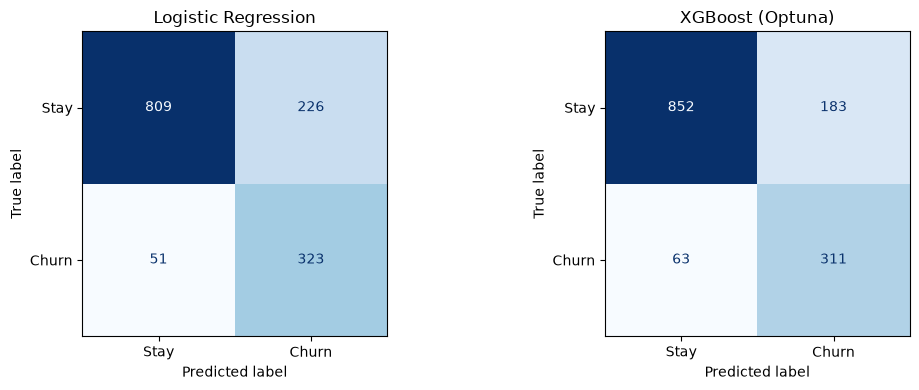

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, pred) in zip(axes, [("Logistic Regression", lr_pred),
                                    ("XGBoost (Optuna)", xgb_pred)]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Stay", "Churn"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


### ROC curves

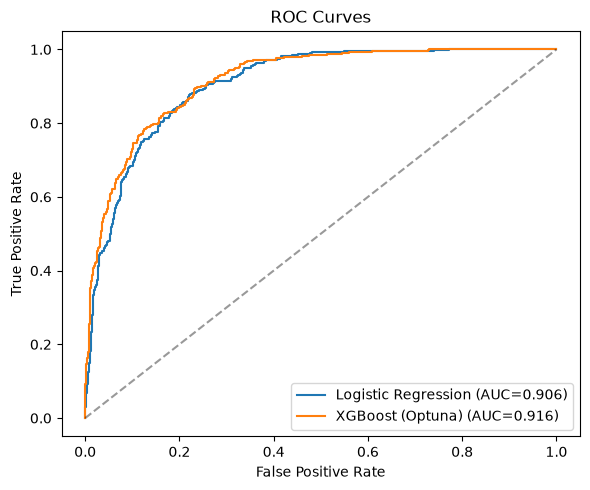

In [23]:
plt.figure(figsize=(6, 5))
for name, proba in [("Logistic Regression", lr_proba), ("XGBoost (Optuna)", xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend(); plt.tight_layout(); plt.show()


### Predicted churn probability — distribution

Distribution of the XGBoost churn score on the test set, split by the actual
outcome. The separation between the two humps is what ROC-AUC summarises into a
single number; seeing it directly is how you choose an operating threshold.

**Caveat:** `scale_pos_weight` is set, so these are *ranking scores*, not
calibrated probabilities — they are inflated relative to the true churn rate.
See the note below the chart.


In [24]:
# Distribution of predicted churn score, split by actual outcome.
THRESHOLD = 0.5   # the operating point; lower it to trade precision for recall

# --- palette: dataviz reference, light surface ---
SURFACE, INK, MUTED = "#fcfcfb", "#0b0b0b", "#898781"
GRID, BASELINE      = "#e1e0d9", "#c3c2b7"
CHURNED, RETAINED   = "#2a78d6", "#008300"   # categorical slots 1 and 2

fig = go.Figure()
for label, mask, color in [
    ("Churned",  y_test == 1, CHURNED),
    ("Retained", y_test == 0, RETAINED),
]:
    fig.add_trace(go.Histogram(
        x=xgb_proba[mask],
        name=label,
        histnorm="percent",              # each class to its own 100% — the classes
                                         # are imbalanced, so raw counts would bury
                                         # the churners
        xbins=dict(start=0.0, end=1.0, size=0.025),
        marker=dict(color=color, line=dict(color=SURFACE, width=1)),
        opacity=0.75,
        hovertemplate=(f"<b>{label}</b><br>score %{{x}}<br>"
                       f"%{{y:.1f}}% of {label.lower()}<extra></extra>"),
    ))

fig.add_vline(
    x=THRESHOLD, line=dict(color=INK, width=2, dash="dash"),
    annotation_text=f"threshold {THRESHOLD:g}", annotation_position="top",
    annotation_font=dict(color=MUTED, size=11),
)

fig.update_layout(
    barmode="overlay", bargap=0.02,
    title=dict(text="Predicted churn score — distribution by actual outcome",
               font=dict(color=INK, size=16)),
    xaxis=dict(title="Predicted churn score", range=[0, 1], gridcolor=GRID,
               linecolor=BASELINE, tickfont=dict(color=MUTED),
               title_font=dict(color=MUTED)),
    yaxis=dict(title="% within class", gridcolor=GRID, linecolor=BASELINE,
               tickfont=dict(color=MUTED), title_font=dict(color=MUTED)),
    plot_bgcolor=SURFACE, paper_bgcolor=SURFACE,
    font=dict(family='system-ui, -apple-system, "Segoe UI", sans-serif'),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1,
                font=dict(color=INK)),
    margin=dict(t=70, r=20, b=50, l=60), height=420,
)
fig.show()

# What the threshold costs you, in customers
above = xgb_proba >= THRESHOLD
print(f"Flagged at {THRESHOLD:g}: {above.sum()} of {len(xgb_proba)} customers")
print(f"  churners caught  : {(above & (y_test == 1)).sum()} of {(y_test == 1).sum()}"
      f"  (recall {(above & (y_test == 1)).sum() / (y_test == 1).sum():.1%})")
print(f"  false alarms     : {(above & (y_test == 0)).sum()}"
      f"  (precision {(above & (y_test == 1)).sum() / above.sum():.1%})")


Flagged at 0.5: 494 of 1409 customers
  churners caught  : 311 of 374  (recall 83.2%)
  false alarms     : 183  (precision 63.0%)


### XGBoost feature importance (top 15)

In [25]:
TOP_N = 15

# --- palette: dataviz reference, light surface ---
SURFACE, INK, SECONDARY, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
SERIES = "#2a78d6"          # slot 1 — one hue for every bar: the features are
                            # nominal, so a darker-where-bigger ramp would just
                            # re-encode bar length as color

imp = (pd.Series(xgb_model.feature_importances_, index=prep_fitted.get_feature_names_out())
         .sort_values(ascending=False).head(TOP_N).sort_values())

BRANCH = {"num__": "numeric · scaled", "ord__": "ordinal · encoded", "cat__": "nominal · one-hot"}
labels = [n.split("__", 1)[1] for n in imp.index]
branches = [BRANCH.get(n.split("__")[0] + "__", "?") for n in imp.index]

# direct-label only the extremes; the axis carries the rest
cut = imp.nlargest(3).min()
text = [f"  {v:.3f}" if v >= cut else "" for v in imp.values]

fig = go.Figure(go.Bar(
    x=imp.values, y=labels, orientation="h",
    marker=dict(color=SERIES, cornerradius=4),
    width=0.62,                       # leave the band's remainder as air
    text=text, textposition="outside",
    textfont=dict(color=SECONDARY, size=11),
    customdata=branches,
    hovertemplate="<b>%{y}</b><br>gain %{x:.4f}<br>%{customdata}<extra></extra>",
))

fig.update_layout(
    title=dict(text=f"XGBoost — top {TOP_N} features by gain",
               font=dict(color=INK, size=16)),
    # headroom so the outside value labels sit inside the plot, never clipped
    xaxis=dict(title="Importance (gain)", range=[0, imp.max() * 1.18],
               gridcolor=GRID, linecolor=BASELINE,
               zerolinecolor=BASELINE, tickfont=dict(color=MUTED),
               title_font=dict(color=MUTED)),
    yaxis=dict(showgrid=False, linecolor=BASELINE, tickfont=dict(color=SECONDARY, size=11)),
    plot_bgcolor=SURFACE, paper_bgcolor=SURFACE,
    font=dict(family='system-ui, -apple-system, "Segoe UI", sans-serif'),
    showlegend=False,                 # one series — the title names it
    margin=dict(t=60, r=95, b=50, l=210),
    height=460, bargap=0.0,
)
fig.show()


---
### Next steps (framework)
- **UMAP + HDBSCAN** on the engineered feature space to form behavioral segments, then fit a
  per-cluster XGBoost and compare against this single global model.
- **SHAP** on the XGBoost model for per-customer / per-cluster driver attribution.
- Feed SHAP drivers into an **LLM** for segment-specific retention recommendations.
  `data/telco_churn_reference.csv` holds `Churn Reason` for validating those
  recommendations after the fact — it is quarantined, never a feature.